In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/hr_raw.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Matplotlib is building the font cache; this may take a moment.


Shape: (1000, 14)
Columns: ['employee_id', 'name', 'age', 'gender', 'department', 'role', 'education', 'hire_date', 'exit_date', 'tenure_years', 'salary', 'performance', 'absences', 'attrition']

Missing values:
 employee_id       0
name              0
age               0
gender            0
department        0
role              0
education         0
hire_date         0
exit_date       836
tenure_years      0
salary            0
performance       0
absences          0
attrition         0
dtype: int64


In [2]:
print("=== Dataset Summary ===")
print(f"Total Employees: {len(df)}")
print(f"Departments: {df['department'].nunique()}")
print(f"Overall Attrition Rate: {round(df['attrition'].mean()*100, 2)}%")
print(f"Average Salary: ${round(df['salary'].mean(), 2)}")
print(f"Average Age: {round(df['age'].mean(), 1)}")
print(f"Average Tenure: {round(df['tenure_years'].mean(), 1)} years")
print("\n=== Attrition by Department ===")
print(df.groupby('department')['attrition'].mean().mul(100).round(2))

=== Dataset Summary ===
Total Employees: 1000
Departments: 6
Overall Attrition Rate: 16.4%
Average Salary: $80255.53
Average Age: 41.0
Average Tenure: 4.9 years

=== Attrition by Department ===
department
Engineering    18.12
Finance        17.58
HR             16.04
Marketing      15.61
Operations     14.53
Sales          16.89
Name: attrition, dtype: float64


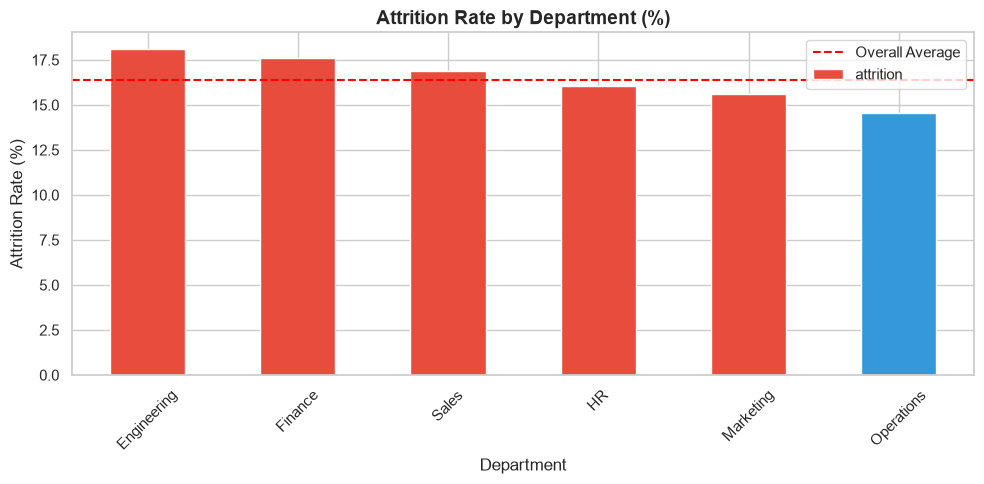

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
attrition_dept = df.groupby('department')['attrition'].mean().mul(100).sort_values(ascending=False)
colors = ['#E74C3C' if x > 15 else '#3498DB' for x in attrition_dept]
attrition_dept.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Attrition Rate by Department (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Attrition Rate (%)')
ax.axhline(y=df['attrition'].mean()*100, color='red', linestyle='--', label='Overall Average')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/eda_charts/01_attrition_by_dept.png', dpi=150)
plt.show()

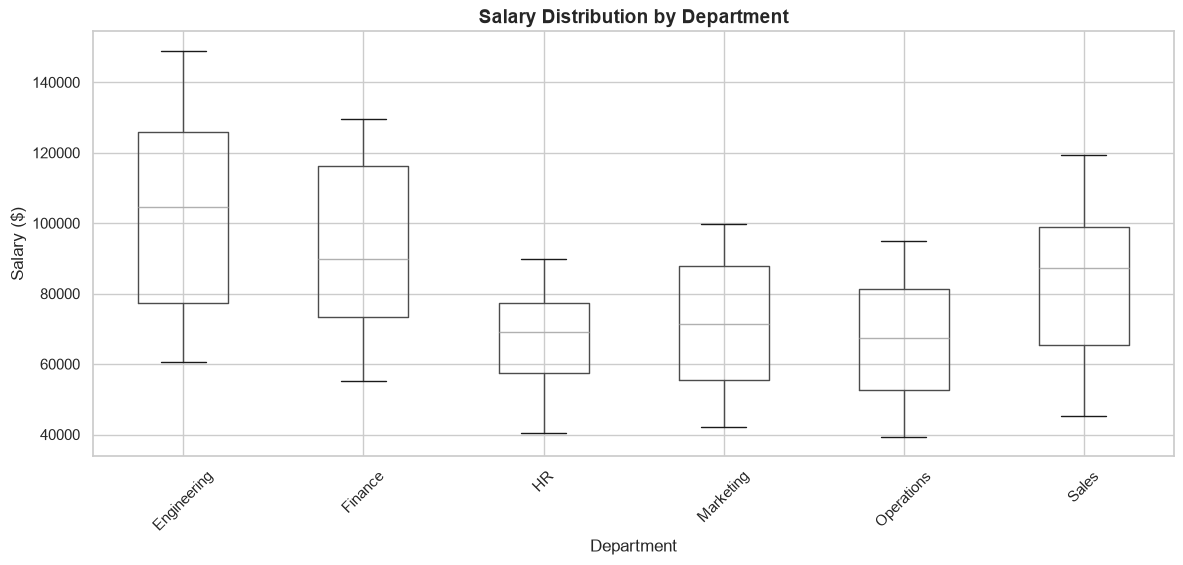

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='salary', by='department', ax=ax)
ax.set_title('Salary Distribution by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Salary ($)')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/eda_charts/02_salary_by_dept.png', dpi=150)
plt.show()

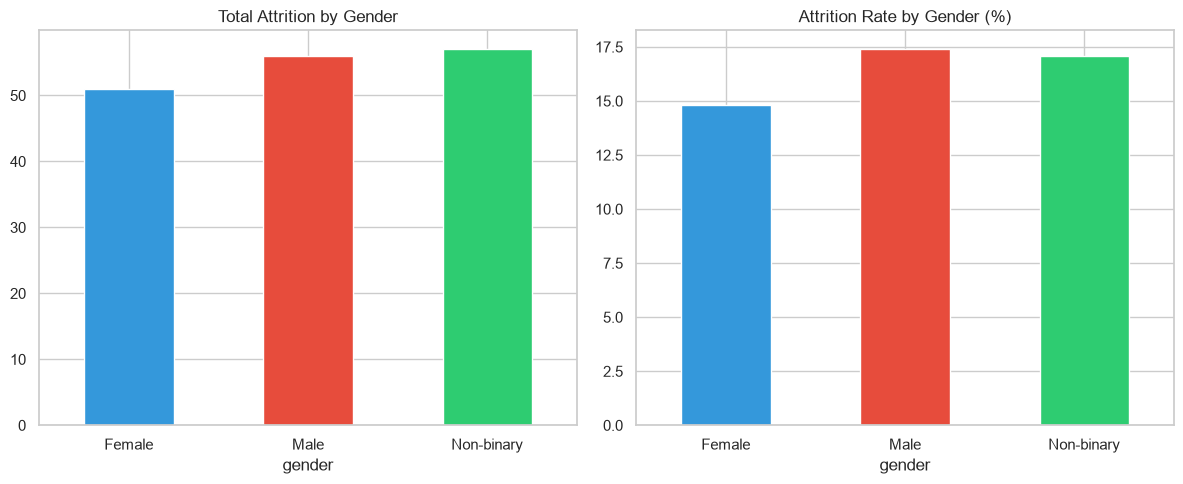

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.groupby('gender')['attrition'].sum().plot(
    kind='bar', ax=axes[0], color=['#3498DB','#E74C3C','#2ECC71'], edgecolor='white')
axes[0].set_title('Total Attrition by Gender')
axes[0].tick_params(axis='x', rotation=0)
df.groupby('gender')['attrition'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color=['#3498DB','#E74C3C','#2ECC71'], edgecolor='white')
axes[1].set_title('Attrition Rate by Gender (%)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../exports/eda_charts/03_attrition_by_gender.png', dpi=150)
plt.show()

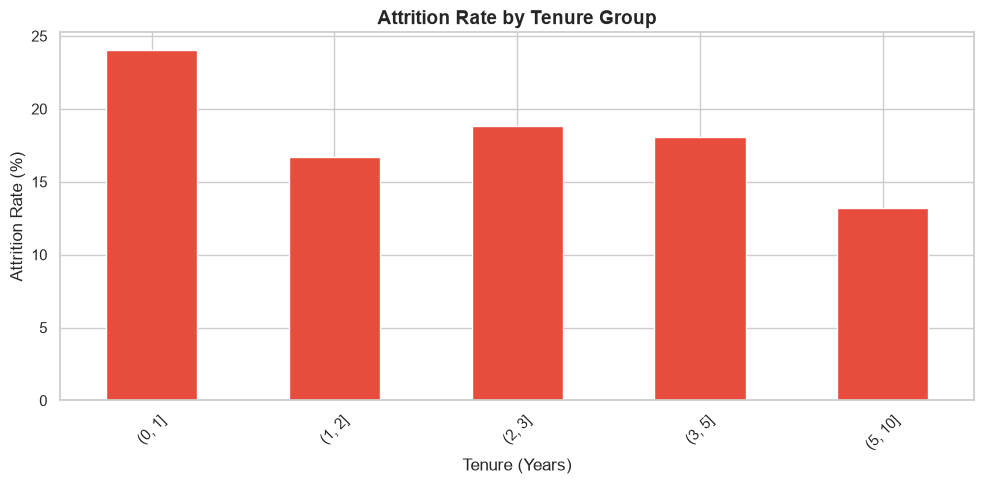

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby(pd.cut(df['tenure_years'], bins=[0,1,2,3,5,10,15]))['attrition']\
  .mean().mul(100).plot(kind='bar', ax=ax, color='#E74C3C', edgecolor='white')
ax.set_title('Attrition Rate by Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/eda_charts/04_attrition_by_tenure.png', dpi=150)
plt.show()

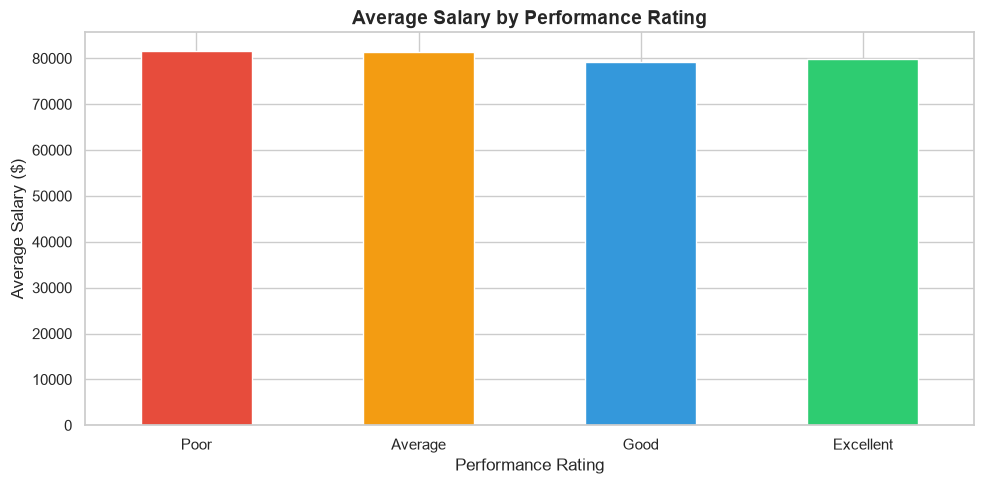

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
order = ['Poor', 'Average', 'Good', 'Excellent']
df.groupby('performance')['salary'].mean().reindex(order)\
  .plot(kind='bar', ax=ax, color=['#E74C3C','#F39C12','#3498DB','#2ECC71'], edgecolor='white')
ax.set_title('Average Salary by Performance Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Performance Rating')
ax.set_ylabel('Average Salary ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../exports/eda_charts/06_salary_by_performance.png', dpi=150)
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv('../data/raw/hr_raw.csv')

# Create Excel writer
with pd.ExcelWriter('../excel/HR_KPI_Reference.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1 - Raw data
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    
    # Sheet 2 - Attrition by department
    attrition = df.groupby('department').agg(
        Total_Employees=('employee_id', 'count'),
        Total_Attrition=('attrition', 'sum'),
        Attrition_Rate=('attrition', lambda x: round(x.mean()*100, 2)),
        Avg_Salary=('salary', lambda x: round(x.mean(), 2)),
        Avg_Tenure=('tenure_years', lambda x: round(x.mean(), 1))
    ).reset_index()
    attrition.to_excel(writer, sheet_name='Attrition by Dept', index=False)
    
    # Sheet 3 - Salary analysis
    salary = df.groupby(['department', 'role']).agg(
        Headcount=('employee_id', 'count'),
        Avg_Salary=('salary', lambda x: round(x.mean(), 2)),
        Min_Salary=('salary', 'min'),
        Max_Salary=('salary', 'max')
    ).reset_index()
    salary.to_excel(writer, sheet_name='Salary Analysis', index=False)
    
    # Sheet 4 - Performance summary
    performance = df.groupby(['department', 'performance']).agg(
        Count=('employee_id', 'count'),
        Avg_Salary=('salary', lambda x: round(x.mean(), 2))
    ).reset_index()
    performance.to_excel(writer, sheet_name='Performance', index=False)
    
    # Sheet 5 - KPI Summary
    kpi_data = {
        'KPI': [
            'Total Employees',
            'Overall Attrition Rate',
            'Average Salary',
            'Average Age',
            'Average Tenure (Years)',
            'Total Departments',
            'Highest Attrition Dept',
            'Lowest Attrition Dept',
            'Top Paying Department',
            'Avg Absences per Employee'
        ],
        'Value': [
            len(df),
            f"{round(df['attrition'].mean()*100, 2)}%",
            f"${round(df['salary'].mean(), 2)}",
            round(df['age'].mean(), 1),
            round(df['tenure_years'].mean(), 1),
            df['department'].nunique(),
            df.groupby('department')['attrition'].mean().idxmax(),
            df.groupby('department')['attrition'].mean().idxmin(),
            df.groupby('department')['salary'].mean().idxmax(),
            round(df['absences'].mean(), 1)
        ]
    }
    kpi_df = pd.DataFrame(kpi_data)
    kpi_df.to_excel(writer, sheet_name='KPI Summary', index=False)

print("Excel file created successfully!")
print("Location: ../excel/HR_KPI_Reference.xlsx")

Excel file created successfully!
Location: ../excel/HR_KPI_Reference.xlsx
